# 02 Network accessibility

We compute network 2SFCA for park and playground access across the 2020 playground closure and the Open Streets response, using the lot pieces from `01_dasymetric_population` as demand points. We write demand point results for both estimators, the sensitivity table, run metadata, and figure inputs to `data/processed/`, which `03_substitution_analysis` and `04_figure_formation` read.

We read NYC Parks properties, the playground closure file, the archived 2020 Open Streets layer, LION 21A, and borough boundaries from `data/raw/`. The OpenStreetMap pedestrian network downloads on the first run in twenty to forty minutes and caches, and later runs take about five minutes.

## Design

All 1,030 playgrounds closed on 31 March 2020 and 814 reopened on 21 and 22 June. Open Streets opened inside that window in four announcement waves on 2, 7, 14, and 23 May, and by 23 May 116 of the eventual 184 corridors had opened in whole or in part, entering the model as 117 supply points. The program added no corridors again until 25 June. We hold the closure constant and vary only the Open Streets supply, so we can separate what the closure removed from what each wave gave back.

We report three quantities for each demand point: loss is the baseline minus the closure, offset is a wave minus the closure, and net is the baseline minus a wave. Net change alone places a block group that lost and recovered heavily in the same position as one that experienced neither.

In [181]:
import json
import sys
import time
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import osmnx as ox
import scipy.sparse as sp
from scipy.sparse.csgraph import dijkstra, connected_components
from scipy.spatial import cKDTree
from shapely import wkt, line_locate_point
from shapely.ops import linemerge, unary_union

sys.path.append("../src")
from paths import RAW, PROCESSED, CRS_PROJECTED

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas")

---
## 1. Configuration

We set every parameter a reader might vary in the next cell, so a rerun with a different value needs no other edits. The catchment is 800 m with binary weights, and Gaussian decay enters the sensitivity analysis. We assign each playground a nominal 4,000 m² footprint, since the closure file records points rather than polygons, and we weight Open Streets by 0.73, the ratio of their 72 weekly operating hours to roughly 98 for parks. We keep full-block closures, including partner-operated ones, and exclude protected bike lanes and outdoor dining, neither of which provides open recreational space. We weight closures by lockability, 1.0 where completely locked, 0.5 where partially locked, and 0 where not lockable, which gives 868 effective closures against 1,030 nominal. Parks and corridors enter the network at every routable node within `ACCESS_M` of their boundary, capped at `MAX_ENTRIES`. We keep two borough lookups, since the closure file and PLUTO code boroughs differently.

In [183]:
DEMAND = PROCESSED / "ceds_pop_nyc_2020.parquet"
PARKS = RAW / "geo_export_8b4f899c-7a19-4f26-8c74-4576d26f7ada.shp"    # NYC Parks Properties
CLOSURES = RAW / "Parks_Closure_Status_Due_to_COVID-19__Playgrounds_20250720.csv"
OPEN_STREETS = RAW / "open_streets_2020" / "open_streets_20210408235257.csv"
BOROUGHS = RAW / "nybb.shp"
LION = RAW / "lion" / "lion.gdb"                                       # 21A, matches the 2021 SegmentIDs
CACHE = RAW / "network_cache"
CACHE.mkdir(exist_ok=True, parents=True)

FT_PER_M = 3.280839895
D0_M = 800                      # 10 minute walk, the convention in park equity work
D0_FT = D0_M * FT_PER_M
DECAY = "binary"                # binary or gaussian
GAUSSIAN_BETA = 0.5

OS_TYPES = ["Full Block", "Full Block - Partner"]   # excludes bike lanes and outdoor dining
OS_HOURS_WEIGHT = 0.73                              # 72h weekly vs ~98h for parks
PLAYGROUND_M2 = 4000                                # nominal footprint
CLOSURE_WEIGHT = {"Completely Locked": 1.0, "Partially Locked": 0.5, "Not Lockable": 0.0}
WAVES = ["2020-05-02", "2020-05-07", "2020-05-14", "2020-05-23"]
WKEY = [d[5:].replace("-", "") for d in WAVES]      # 0502, 0507, 0514, 0523

MIN_POP = 0.5                   # demand points below this: 13% of pieces, 0.02% of population
MIN_COMP = 50                   # components smaller than this are OSM stubs
MAX_SNAP_M = 250                # parks snapped farther than this are dropped

ACCESS_M = 25                   # a node this close to a boundary counts as an entrance
MAX_ENTRIES = 40                # per supply point, spaced evenly along the boundary
NODE_BATCH = 400                # entrance nodes routed at once; lower if memory is tight

BORO_NAMES = {"B": "Brooklyn", "M": "Manhattan", "Q": "Queens",
              "R": "Staten Island", "X": "Bronx"}                # closures file
PLUTO_BORO = {"BK": "Brooklyn", "MN": "Manhattan", "QN": "Queens",
              "SI": "Staten Island", "BX": "Bronx"}              # PLUTO, via the demand surface

---
## 2. Pedestrian network

We download the pedestrian network from OpenStreetMap with the OSMnx walk filter and model walking on street centerlines, since OSM sidewalk tagging is uneven outside Manhattan. We take the city extent from the DCP borough boundaries, keep all components (`retain_all=True`) so the connectivity check can find coverage gaps, and keep edges crossing the boundary (`truncate_by_edge=True`) so waterfront routes stay intact. The graph caches to `data/raw/network_cache`, and deleting the graphml forces a rebuild. OpenStreetMap changes over time, so a rebuild will not reproduce our network exactly, and we archive the cached graphml with the code release. `project_graph` puts node coordinates in feet but leaves edge lengths in meters, so we convert lengths to feet when we build the routing matrix.

In [185]:
GRAPHML = CACHE / "nyc_walk.graphml"

if GRAPHML.exists():
    G = ox.load_graphml(GRAPHML)
else:
    poly = gpd.read_file(BOROUGHS).to_crs("EPSG:4326").union_all()
    print("downloading from OSM, 20-40 minutes")
    t0 = time.time()
    G = ox.graph_from_polygon(poly, network_type="walk", simplify=True,
                              retain_all=True, truncate_by_edge=True)
    ox.save_graphml(G, GRAPHML)
    print(f"downloaded in {time.time() - t0:,.0f}s")

G = ox.project_graph(G, to_crs=CRS_PROJECTED)   # node coords in feet; edge length stays in meters
print(f"{G.number_of_nodes():,} nodes  |  {G.number_of_edges():,} edges  |  osmnx {ox.__version__}")

354,173 nodes  |  1,089,428 edges  |  osmnx 2.1.1


### Connectivity

A disconnected component returns an infinite distance, which enters accessibility as a zero that looks identical to a real absence of access. The largest component holds 77% of nodes, while Staten Island forms its own component of 59,794 nodes and the Rockaways another of 8,774, so restricting the network to the largest component would remove an entire borough. We retain all components and exclude edges on components under `MIN_COMP` nodes before attaching demand points, so no demand point sits on a fragment with no route. The 3,433 small components hold 9,679 nodes, 2,955 of them isolated pairs such as driveways and unconnected footpaths.

In [187]:
nodes = list(G.nodes())
idx = {n: i for i, n in enumerate(nodes)}

r, c, v = [], [], []
for u, w, d in G.edges(data=True):
    if d.get("length") is None:
        continue
    r.append(idx[u]); c.append(idx[w]); v.append(float(d["length"]) * FT_PER_M)   # meters to feet

# parallel edges keep the shortest length; csr_matrix would sum them
e = pd.DataFrame({"r": r, "c": c, "v": v}).groupby(["r", "c"], as_index=False)["v"].min()
M = sp.csr_matrix((e["v"], (e["r"], e["c"])), shape=(len(nodes), len(nodes)))

node_ids = np.array(nodes)
node_xy = np.array([[G.nodes[n]["x"], G.nodes[n]["y"]] for n in nodes])

n_comp, comp_labels = connected_components(M, directed=True, connection="weak")
sizes = pd.Series(comp_labels).value_counts()

print(f"{M.shape[0]:,} nodes  |  {len(v) - len(e):,} parallel edges collapsed  |  {n_comp:,} weakly connected components")
print(f"largest: {sizes.iloc[0]:,} ({sizes.iloc[0] / len(comp_labels):.2%})")
print(sizes.head(6).to_string())

354,173 nodes  |  9,296 parallel edges collapsed  |  3,452 weakly connected components
largest: 272,769 (77.02%)
0      272769
275     59794
159      8774
18       1232
79        373
489       237


In [188]:
big = sizes >= MIN_COMP
routable = np.isin(comp_labels, sizes.index[big])

print(f">= {MIN_COMP} nodes: {big.sum():,} components, {sizes[big].sum():,} nodes")
print(f"<  {MIN_COMP} nodes: {(~big).sum():,} components, {sizes[~big].sum():,} nodes")
print("\ntail sizes:")
print(sizes[~big].value_counts().sort_index().head(6).to_string())

>= 50 nodes: 19 components, 344,494 nodes
<  50 nodes: 3,433 components, 9,679 nodes

tail sizes:
count
2    2955
3       6
4     210
5      20
6      57
7      21


In [189]:
boros = gpd.read_file(BOROUGHS).to_crs(CRS_PROJECTED)[["BoroName", "geometry"]]

pts = gpd.GeoDataFrame({"comp": comp_labels},
                       geometry=gpd.points_from_xy(node_xy[:, 0], node_xy[:, 1]),
                       crs=CRS_PROJECTED)
nb = gpd.sjoin(pts, boros, how="left", predicate="within")

for c in sizes.index[:4]:
    sub = nb[nb["comp"] == c]
    top = sub["BoroName"].value_counts()
    where = ", ".join(f"{k} {v:,}" for k, v in top.head(2).items())
    print(f"component {c}: {len(sub):,} nodes  |  {where}")

component 0: 272,769 nodes  |  Queens 125,225, Brooklyn 69,072
component 275: 59,794 nodes  |  Staten Island 59,788
component 159: 8,774 nodes  |  Queens 8,738
component 18: 1,232 nodes  |  Manhattan 1,226


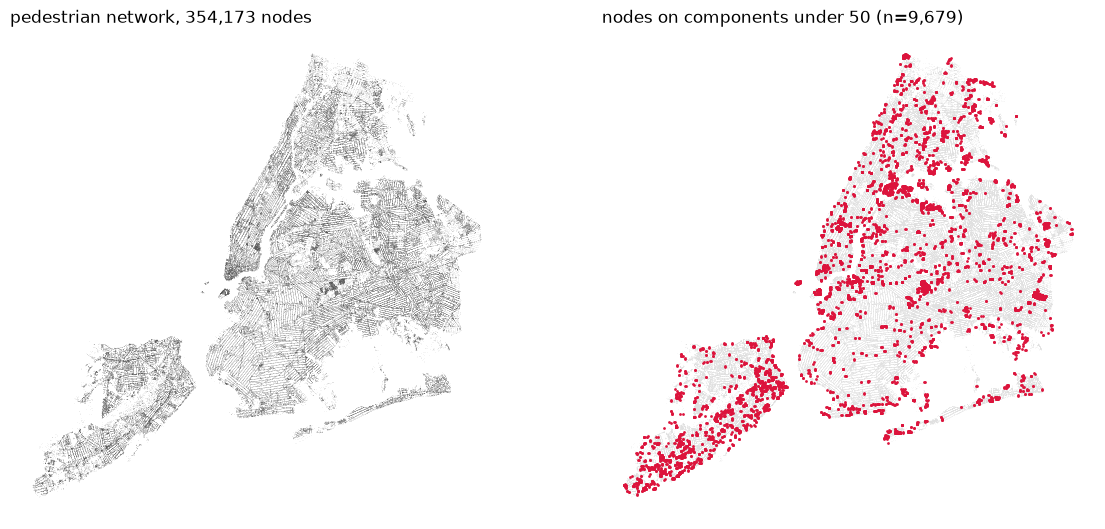

In [190]:
frag = ~routable

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].scatter(node_xy[:, 0], node_xy[:, 1], s=0.02, c="0.35", linewidths=0)
axes[0].set_title(f"pedestrian network, {len(node_xy):,} nodes", loc="left")

axes[1].scatter(node_xy[~frag, 0], node_xy[~frag, 1], s=0.05, c="0.88", linewidths=0)
axes[1].scatter(node_xy[frag, 0], node_xy[frag, 1], s=4, c="crimson", linewidths=0)
axes[1].set_title(f"nodes on components under {MIN_COMP} (n={frag.sum():,})", loc="left")

for a in axes:
    a.set_aspect("equal")
    a.axis("off")

---
## 3. Supply

Parks stay open in every scenario, playgrounds carry the closure, and Open Streets enter on their opening date. We measure capacity in square meters as park area, 4,000 m² per playground, and length times width times 0.73 for corridors, and the closure scenario removes each playground's capacity in proportion to its closure weight. We use the square root of capacity as attractiveness in the competition denominator, so a large park such as Central Park does not absorb nearly all the demand of the residents within reach of it, while capacity itself stays additive and splitting or merging records leaves total supply unchanged.

We read playground locations and closure types from the NYC Parks closure file. We clip park polygons to the borough shoreline, since piers, marinas, and bay parkland extend into open water and would otherwise count as capacity, which reduces park area from 117.2 km² to 99.2 km².

In [192]:
pg = pd.read_csv(CLOSURES)
pg["closed_dt"] = pd.to_datetime(pg["Approx Date Closed"], errors="coerce")
pg["reopen_dt"] = pd.to_datetime(pg["Approx Date Reopened"], errors="coerce")
pg["close_w"] = pg["ClosureType"].map(CLOSURE_WEIGHT)

playgrounds = gpd.GeoDataFrame(pg, crs="EPSG:4326",
                               geometry=gpd.points_from_xy(pg["Longitude"], pg["Latitude"])
                               ).to_crs(CRS_PROJECTED)
playgrounds["pg_id"] = playgrounds["OMPpropID"].astype(str).str.strip().str.upper()

print(f"{len(playgrounds):,} playgrounds, {playgrounds['close_w'].sum():,.0f} effective closures")
print(playgrounds["ClosureType"].value_counts(dropna=False).to_string())
print(f"unmapped closure type: {playgrounds['close_w'].isna().sum()}  |  "
      f"missing coordinates: {pg[['Longitude', 'Latitude']].isna().any(axis=1).sum()}")
print(f"closed: {playgrounds['closed_dt'].min()} to {playgrounds['closed_dt'].max()}")
print(f"reopened 21-22 June: {playgrounds['reopen_dt'].between('2020-06-21', '2020-06-22').sum():,}  |  "
      f"no reopen date: {playgrounds['reopen_dt'].isna().sum()}")

1,030 playgrounds, 868 effective closures
ClosureType
Completely Locked    790
Partially Locked     155
Not Lockable          85
unmapped closure type: 0  |  missing coordinates: 0
closed: 2020-03-31 00:00:00 to 2020-03-31 00:00:00
reopened 21-22 June: 814  |  no reopen date: 43


In [193]:
parks = gpd.read_file(PARKS).to_crs(CRS_PROJECTED)
parks = parks[parks.geometry.notna() & ~parks.geometry.is_empty].copy()

# parks file is not clipped to the shoreline; piers and bay parkland would count as capacity
land = boros.union_all()
n0, a0 = len(parks), parks.geometry.area.sum() / (FT_PER_M ** 2) / 1e6
parks["geometry"] = parks.geometry.intersection(land)
parks = parks[~parks.geometry.is_empty].reset_index(drop=True)

parks["park_id"] = parks["omppropid"].astype(str).str.strip().str.upper()
parks["area_m2"] = parks.geometry.area / (FT_PER_M ** 2)

print(f"{n0:,} parks, {a0:,.1f} km2 -> {len(parks):,} parks, {parks['area_m2'].sum()/1e6:,.1f} km2 after clipping")

2,054 parks, 117.2 km2 -> 2,053 parks, 99.2 km2 after clipping


### Open Streets

We use an April 2021 Wayback capture of NYC Open Data dataset `uiay-nctu`, committed to this repository since the live dataset no longer serves 2020 records. We filter to full-block closures, deduplicate on `SegmentID`, since the capture repeats 31% of rows unevenly by borough, drop segments inside park polygons already counted as park supply, and join street widths from LION 21A, whose `SegmentID` values match this vintage. We then merge contiguous segments into corridors, so a multi-block Open Street counts as one supply point with its full length, as a park counts as one supply point with its full area. Nine corridors join blocks that opened on different dates, and seven of them span more than one wave, so we split corridors by wave and each block enters the model on its own date. Each block entering as its own supply point raises the offset under competition weighting, which we report in the sensitivity analysis.

In [195]:
os_raw = pd.read_csv(OPEN_STREETS)
os_raw.columns = [c.strip() for c in os_raw.columns]
os_raw["open_dt"] = pd.to_datetime(os_raw["Open Date"], errors="coerce", format="mixed")

n0 = len(os_raw)
os_f = os_raw[os_raw["Type"].isin(OS_TYPES) & os_raw["the_geom"].notna()]
n1 = len(os_f)
dates_per_seg = os_f.groupby("SegmentID")["open_dt"].nunique()
os_f = os_f.sort_values("open_dt").drop_duplicates(subset="SegmentID")   # keep earliest date
n2 = len(os_f)

streets = gpd.GeoDataFrame(os_f.drop(columns="the_geom"),
                           geometry=[wkt.loads(w) for w in os_f["the_geom"]],
                           crs="EPSG:4326").to_crs(CRS_PROJECTED)

# segments inside park polygons are already counted as park supply
rp = streets.assign(geometry=streets.geometry.representative_point())
j = gpd.sjoin(rp, parks[["park_id", "geometry"]], how="left", predicate="within")
j = j[~j.index.duplicated(keep="first")]
streets = streets[j["park_id"].isna().values].reset_index(drop=True)

streets["length_m"] = streets.geometry.length / FT_PER_M
streets["seg7"] = streets["SegmentID"].astype(str).str.zfill(7)

print(f"{n0:,} records -> {n1:,} full-block -> {n2:,} deduplicated -> {len(streets):,} outside parks")
print(f"segments with conflicting open dates: {(dates_per_seg > 1).sum()}")
print(f"{streets['length_m'].sum()/1609:.1f} miles  |  missing open date: {streets['open_dt'].isna().sum()}")
print(streets.groupby("Borough")["length_m"].agg(n="size", meters="sum").round(0).to_string())

1,607 records -> 1,271 full-block -> 879 deduplicated -> 817 outside parks
segments with conflicting open dates: 0
36.3 miles  |  missing open date: 0
                 n      meters
Borough                       
Bronx          113  8,043.0000
Brooklyn       287 21,807.0000
Manhattan      186 13,481.0000
Queens         206 13,027.0000
Staten Island   25  2,106.0000


In [196]:
lion = gpd.read_file(LION, layer="lion", columns=["SegmentID", "StreetWidth_Min"])
w = lion.drop_duplicates("SegmentID").set_index("SegmentID")["StreetWidth_Min"]

# LION zero-pads SegmentID to 7 chars; the Open Streets file stores it as int
streets["width_m"] = pd.to_numeric(streets["seg7"].map(w), errors="coerce") / FT_PER_M
n_fill = streets["width_m"].isna().sum()
streets["width_m"] = streets["width_m"].fillna(streets.groupby("Borough")["width_m"].transform("median"))

print(f"{n_fill} of {len(streets)} widths filled with borough median")
print(streets["width_m"].describe().round(1).to_string())

68 of 817 widths filled with borough median
count   817.0000
mean     11.1000
std       2.7000
min       4.6000
25%       9.1000
50%      10.4000
75%      12.2000
max      18.3000


In [197]:
streets = streets.drop(columns=["corr_id", "first_wave"], errors="ignore")

# linemerge joins touching segments into continuous corridors
merged = linemerge(unary_union(streets.geometry.values))
parts = gpd.GeoDataFrame(geometry=list(merged.geoms), crs=CRS_PROJECTED).reset_index(names="corr_id")

rp = streets.assign(geometry=streets.geometry.representative_point())
j = gpd.sjoin_nearest(rp, parts, how="left")
streets["corr_id"] = j[~j.index.duplicated(keep="first")]["corr_id"].values

# 0-3 index the wave a block first counts in; 4 = after 23 May
streets["first_wave"] = np.searchsorted(pd.to_datetime(WAVES).values, streets["open_dt"].values, side="left")

# blocks from different waves stay separate, so each enters on its own date
corridors = streets.dissolve(
    by=["corr_id", "first_wave"],
    aggfunc={"length_m": "sum", "Borough": "first", "On Street": "first", "open_dt": "min"}
).reset_index()

width = streets.groupby(["corr_id", "first_wave"]).apply(
    lambda g: np.average(g["width_m"], weights=g["length_m"]), include_groups=False)
corridors["width_m"] = [width[(c, w)] for c, w in zip(corridors["corr_id"], corridors["first_wave"])]
corridors["os_id"] = corridors["corr_id"].astype(str) + "_" + corridors["first_wave"].astype(str)

n = streets.groupby("corr_id").size()
split = corridors.groupby("corr_id").size()
print(f"{len(streets):,} segments -> {streets['corr_id'].nunique()} corridors -> {len(corridors)} supply points, "
      f"{corridors['length_m'].sum()/1609:.1f} miles")
print(f"segments per corridor: median {n.median():.0f}, max {n.max()}")
print(f"corridors split by wave: {(split > 1).sum()}")
print(f"open by {WAVES[-1]}: {(corridors['first_wave'] < len(WAVES)).sum()} supply points")
print(corridors.groupby("Borough").agg(supply_points=("os_id", "size"),
                                       km=("length_m", lambda v: v.sum() / 1000)).round(1).to_string())
print("\nlongest:")
print(corridors.nlargest(5, "length_m")[["Borough", "On Street", "length_m", "width_m"]].round(1).to_string())

817 segments -> 184 corridors -> 191 supply points, 36.3 miles
segments per corridor: median 3, max 27
corridors split by wave: 7
open by 2020-05-23: 117 supply points
               supply_points      km
Borough                             
Bronx                     21  8.0000
Brooklyn                  70 21.8000
Manhattan                 55 13.5000
Queens                    40 13.0000
Staten Island              5  2.1000

longest:
           Borough            On Street   length_m  width_m
2    Staten Island          Bank Street 1,413.5000   6.7000
159         Queens             34th Ave 1,369.4000  10.4000
84       Manhattan     WEST  117 STREET 1,133.9000   9.2000
166          Bronx       HOLLAND AVENUE 1,008.9000   9.6000
164          Bronx  Reservoir Oval West 1,008.5000   9.2000


In [198]:
# the program's longest Open Street should resolve to one corridor, split only by wave
sub = streets[streets["On Street"].str.contains("34th Ave", na=False) & (streets["Borough"] == "Queens")]
pts = corridors[corridors["corr_id"].isin(sub["corr_id"])]
print(f"34th Ave: {len(sub)} segments, {sub['corr_id'].nunique()} corridor(s), {len(pts)} supply points, "
      f"{sub['length_m'].sum():.0f} m")
print(pts[["os_id", "open_dt"]].assign(length_m=pts["length_m"].round(0)).to_string(index=False))

34th Ave: 27 segments, 1 corridor(s), 2 supply points, 2086 m
os_id    open_dt   length_m
163_1 2020-05-07   716.0000
163_2 2020-05-14 1,369.0000


In [199]:
# capacity is additive, so the dissolve must not change the total
seg_cap = (streets["length_m"] * streets["width_m"] * OS_HOURS_WEIGHT).sum()
corr_cap = (corridors["length_m"] * corridors["width_m"] * OS_HOURS_WEIGHT).sum()
print(f"segments {seg_cap:,.0f} m2  |  corridors {corr_cap:,.0f} m2  |  "
      f"difference {abs(corr_cap - seg_cap) / seg_cap:.4%}")

segments 444,907 m2  |  corridors 444,907 m2  |  difference 0.0000%


### Supply points on the network

We anchor each supply point to one node, snapping parks to the node nearest their boundary rather than their centroid, since the centroids of large parks sit hundreds of meters from any street, and snapping playgrounds and corridors to the node nearest their representative point. We re-snap the 56 supply points that land on components under `MIN_COMP` nodes. Four parks remain farther than `MAX_SNAP_M` from any routable node (Shooters Island, South Brother Island, Mill Rock, and Isle of Meadows), and we drop them, since their snapped points would credit mainland residents with parkland they cannot walk to. The anchor serves as the only entrance for playgrounds and for parks without street frontage, and the entrance cells below add the rest.

In [201]:
def snap_boundary(gdf, node_xy):
    tree = cKDTree(node_xy)
    node_i, snap_ft = [], []

    for geom in gdf.geometry.boundary:
        if geom.geom_type == "LineString":
            coords = np.asarray(geom.coords)
        else:
            coords = np.vstack([np.asarray(g.coords) for g in geom.geoms])
        if len(coords) > 5000:
            coords = coords[:: max(1, len(coords) // 5000)]   # cap the query on complex boundaries

        d, i = tree.query(coords, k=1)
        k = int(np.argmin(d))
        node_i.append(int(i[k]))
        snap_ft.append(float(d[k]))

    return np.array(node_i), np.array(snap_ft) / FT_PER_M


parks["node_i"], parks["snap_m"] = snap_boundary(parks, node_xy)
print(f"park snap (m): median {parks['snap_m'].median():.0f}  "
      f"p95 {parks['snap_m'].quantile(.95):.0f}  max {parks['snap_m'].max():,.0f}")

park snap (m): median 3  p95 44  max 319


In [202]:
tree = cKDTree(node_xy)

for gdf, label in [(playgrounds, "playground"), (corridors, "corridor")]:
    rp = gdf.geometry.representative_point()
    d, i = tree.query(np.c_[rp.x, rp.y], k=1)
    gdf["node_i"] = i                      # mutates playgrounds / corridors in place
    gdf["snap_m"] = d / FT_PER_M
    print(f"{label} snap (m): median {gdf['snap_m'].median():.0f}  "
          f"p95 {gdf['snap_m'].quantile(.95):.0f}  max {gdf['snap_m'].max():,.0f}")

playground snap (m): median 29  p95 65  max 116
corridor snap (m): median 9  p95 35  max 118


In [203]:
ok_idx = np.flatnonzero(routable)
ok_xy = node_xy[ok_idx]
n_resnapped = 0

for gdf, label in [(parks, "park"), (playgrounds, "playground"), (corridors, "corridor")]:
    comp_size = pd.Series(comp_labels[gdf["node_i"].values]).map(sizes).values
    bad = comp_size < MIN_COMP
    if not bad.any():
        print(f"{label}: none stranded")
        continue

    n_resnapped += int(bad.sum())

    if label == "park":
        ni, sm = snap_boundary(gdf[bad], ok_xy)
    else:
        rp = gdf.loc[bad].geometry.representative_point()
        d, i = cKDTree(ok_xy).query(np.c_[rp.x, rp.y], k=1)
        ni, sm = i, d / FT_PER_M

    gdf.loc[bad, "node_i"] = ok_idx[ni]
    gdf.loc[bad, "snap_m"] = sm
    print(f"{label}: re-snapped {bad.sum()}, new snap (m) median {np.median(sm):.0f} max {sm.max():,.0f}")

park: re-snapped 38, new snap (m) median 8 max 584
playground: re-snapped 17, new snap (m) median 36 max 161
corridor: re-snapped 1, new snap (m) median 8 max 8


In [204]:
far = parks["snap_m"] > MAX_SNAP_M
n_dropped = int(far.sum())

if n_dropped:
    print(f"dropping {n_dropped} parks beyond {MAX_SNAP_M} m from any routable node:")
    print(parks.loc[far, ["signname", "area_m2", "snap_m"]].round(0).to_string(index=False))
    parks = parks[~far].reset_index(drop=True)
else:
    print("no parks beyond the snap threshold")

dropping 4 parks beyond 250 m from any routable node:
            signname      area_m2   snap_m
South Brother Island  22,102.0000 263.0000
     Isle Of Meadows 352,802.0000 584.0000
      Mill Rock Park  10,812.0000 361.0000
     Shooters Island  66,478.0000 289.0000


### Entrances

We connect each park and corridor to the network at every routable node within `ACCESS_M` of its boundary, so a resident reaches it through the nearest entrance rather than through a single snapped node, which would make a large park reachable only from one point on its edge. We cap entrances at `MAX_ENTRIES` for each supply point, spaced evenly along the boundary or corridor, which keeps routing tractable while still placing an entrance about every 250 m around Central Park. Parks with no routable node within `ACCESS_M`, most of them marshes and wetlands without street frontage, keep their anchor node, as do all playgrounds.

In [206]:
ACCESS_FT = ACCESS_M * FT_PER_M

nodes_gdf = gpd.GeoDataFrame({"node_i": ok_idx},
                             geometry=gpd.points_from_xy(node_xy[ok_idx, 0], node_xy[ok_idx, 1]),
                             crs=CRS_PROJECTED)

def entry_nodes(ids, lines):
    band = gpd.GeoDataFrame({"sid": np.asarray(ids)},
                            geometry=lines.buffer(ACCESS_FT).values, crs=CRS_PROJECTED)
    hit = gpd.sjoin(nodes_gdf, band, predicate="within")[["sid", "node_i"]]
    geo = dict(zip(ids, lines.values))

    out = {}
    for sid, g in hit.groupby("sid"):
        n = g["node_i"].values
        pos = line_locate_point(np.repeat(geo[sid], len(n)), gpd.points_from_xy(*node_xy[n].T))
        n = n[np.argsort(pos)]
        if len(n) > MAX_ENTRIES:
            n = n[np.linspace(0, len(n) - 1, MAX_ENTRIES).round().astype(int)]
        out[sid] = n
    return out

park_entries = entry_nodes(parks["park_id"].values, parks.geometry.boundary)
corr_entries = entry_nodes(corridors["os_id"].values, corridors.geometry)

for lab, d, gdf, key in [("parks", park_entries, parks, "park_id"),
                         ("corridors", corr_entries, corridors, "os_id")]:
    cnt = pd.Series({k: len(v) for k, v in d.items()})
    missing = set(gdf[key]) - set(d)
    print(f"{lab}: {len(d):,} with entrances, {len(missing)} with none  |  "
          f"entrances median {cnt.median():.0f}, max {cnt.max()}, total {cnt.sum():,}")

print(f"\nunique entrance nodes: {len(set(np.concatenate(list(park_entries.values()) + list(corr_entries.values())))):,}")

parks: 1,817 with entrances, 232 with none  |  entrances median 11, max 40, total 27,761
corridors: 191 with entrances, 0 with none  |  entrances median 17, max 40, total 3,676

unique entrance nodes: 29,229


In [207]:
# parks with no node within ACCESS_M keep their single snapped node
for pid, ni in parks.loc[~parks["park_id"].isin(park_entries), ["park_id", "node_i"]].values:
    park_entries[pid] = np.array([int(ni)])

no_entry = parks[~parks["park_id"].isin(
    [k for k, v in park_entries.items() if len(v) > 1])]
print(f"{len(no_entry)} parks on a single node, {no_entry['area_m2'].sum() / 1e6:.2f} km2, "
      f"{100 * no_entry['area_m2'].sum() / parks['area_m2'].sum():.1f}% of park area")
print(no_entry.nlargest(5, "area_m2")[["signname", "area_m2", "snap_m"]].round(0).to_string(index=False))

304 parks on a single node, 1.34 km2, 1.4% of park area
              signname      area_m2   snap_m
         Pralls Island 341,833.0000 188.0000
    Four Sparrow Marsh 197,470.0000  46.0000
  Old Place Creek Park 177,191.0000  38.0000
Broad Channel Wetlands  86,014.0000  45.0000
        Meredith Woods  63,032.0000  66.0000


### Supply table

We hold every supply point in one table with its capacity, closure weight, and opening date, and each scenario reads those columns differently, so the 2SFCA code stays identical across runs. Open Streets add 0.44 km² of weighted capacity against the 3.47 km² of playground capacity the closure withdraws, so any offset reflects redistributed proximity rather than replaced area.

In [209]:
supply = pd.concat([
    pd.DataFrame({"kind": "park",
                  "sid": parks["park_id"].values,
                  "node_i": parks["node_i"].values,
                  "capacity": parks["area_m2"].values,
                  "close_w": 0.0,
                  "open_dt": pd.NaT}),
    pd.DataFrame({"kind": "playground",
                  "sid": playgrounds["pg_id"].values,
                  "node_i": playgrounds["node_i"].values,
                  "capacity": float(PLAYGROUND_M2),
                  "close_w": playgrounds["close_w"].values,
                  "open_dt": pd.NaT}),
    pd.DataFrame({"kind": "openstreet",
                  "sid": corridors["os_id"].values,
                  "node_i": corridors["node_i"].values,
                  "capacity": (corridors["length_m"] * corridors["width_m"] * OS_HOURS_WEIGHT).values,
                  "close_w": 0.0,
                  "open_dt": corridors["open_dt"].values}),
], ignore_index=True)

print(supply.groupby("kind").agg(n=("sid", "size"),
                                 cap_km2=("capacity", lambda v: v.sum() / 1e6)).round(2).to_string())

pg = supply["kind"] == "playground"
print(f"\nplayground capacity withdrawn at closure: "
      f"{(supply.loc[pg, 'capacity'] * supply.loc[pg, 'close_w']).sum() / 1e6:.2f} km2")

               n  cap_km2
kind                     
openstreet   191   0.4400
park        2049  98.7700
playground  1030   4.1200

playground capacity withdrawn at closure: 3.47 km2


### Descriptive summary

Parks, closures and corridors by borough, with corridors per 100 effective
closures as a raw offset rate. This runs before the modelling, since the gradient
it shows is what the accessibility results have to explain, and a reader should
be able to see how much of the result is already visible in the counts.

Park area is apportioned by overlay rather than assigned whole, since 14 parks
straddle a borough line and two of them are over a square kilometer.

In [211]:
pieces_b = gpd.overlay(parks[["park_id", "geometry"]], boros, how="intersection")
pieces_b["area_m2"] = pieces_b.geometry.area / (FT_PER_M ** 2)
park_b = pieces_b.groupby("BoroName").agg(parks=("park_id", "nunique"),
                                          park_km2=("area_m2", lambda v: v.sum() / 1e6))

pg_b = playgrounds.assign(BoroName=playgrounds["Borough"].map(BORO_NAMES))
play_b = pg_b.groupby("BoroName").agg(playgrounds=("pg_id", "size"), effective_closed=("close_w", "sum"))

rep = corridors.assign(geometry=corridors.geometry.representative_point())
corr_b = gpd.sjoin(rep[["corr_id", "length_m", "geometry"]], boros, how="left", predicate="within") \
            .groupby("BoroName").agg(corridors=("corr_id", "nunique"), os_km=("length_m", lambda v: v.sum() / 1000))

boro_table = park_b.join(play_b).join(corr_b)
boro_table["corridors_per_100_closed"] = 100 * boro_table["corridors"] / boro_table["effective_closed"]

print(f"parks crossing a borough line: {(pieces_b.groupby('park_id')['BoroName'].nunique() > 1).sum()}")
print(boro_table.round(2).to_string())

parks crossing a borough line: 14
               parks  park_km2  playgrounds  effective_closed  corridors   os_km  corridors_per_100_closed
BoroName                                                                                                  
Bronx            398   23.2900          206          162.0000         21  8.0400                   12.9600
Brooklyn         630   14.8600          292          272.0000         67 21.8100                   24.6300
Manhattan        399   10.1800          208          187.5000         54 13.4800                   28.8000
Queens           478   24.4900          261          197.5000         37 13.0300                   18.7300
Staten Island    158   25.9500           63           48.5000          5  2.1100                   10.3100


---
## 4. Demand points

We keep each lot piece as its own demand point rather than moving it to a network node, attach it to the nearest street edge, and measure its distance to a supply point as the connector plus the shorter path through either endpoint. We drop pieces below half a person, 13% of pieces and 0.02% of population, which leaves 769,601 demand points holding 8,798,936 people. The median connector is 16.9 m with a 95th percentile of 24.7 m, and the 395 demand points beyond 250 m hold 2,074 people, most of them in Brooklyn. We keep one edge for each street, dropping the reverse copy that OSM stores for two-way streets while keeping 3,970 parallel streets between the same two nodes, and we exclude edges on components under `MIN_COMP` nodes.

In [213]:
demand = pd.read_parquet(DEMAND)
demand = demand[demand["pop_ceds"] >= MIN_POP]
demand = gpd.GeoDataFrame(demand, crs=CRS_PROJECTED,
                          geometry=gpd.points_from_xy(demand["x"], demand["y"]))

edges = ox.graph_to_gdfs(G, nodes=False).reset_index()
npos = {n: i for i, n in enumerate(node_ids)}
edges["ui"] = edges["u"].map(npos)
edges["vi"] = edges["v"].map(npos)

edges = edges[routable[edges["ui"].values] & routable[edges["vi"].values]]

# drop the reverse copy of two-way streets; parallel streets differ in length and stay
n_directed = len(edges)
pair = np.sort(edges[["ui", "vi"]].values, axis=1)
edges["elen_ft"] = edges.geometry.length
edges = (edges.assign(_a=pair[:, 0], _b=pair[:, 1], _len=edges["elen_ft"].round(1))
              .drop_duplicates(["_a", "_b", "_len"]).reset_index(drop=True))
n_parallel = len(edges) - len(np.unique(np.sort(edges[["ui", "vi"]].values, axis=1), axis=0))

# offsets are measured from the geometry start, which is not guaranteed to be u
first = np.array([g.coords[0] for g in edges.geometry])
flip = (np.linalg.norm(first - node_xy[edges["ui"].values], axis=1)
        > np.linalg.norm(first - node_xy[edges["vi"].values], axis=1))

print(f"{len(demand):,} pieces above {MIN_POP} persons")
print(f"{n_directed:,} directed edges -> {len(edges):,} undirected  |  {n_parallel:,} parallel kept  |  "
      f"{flip.sum():,} with geometry running v to u")

769,601 pieces above 0.5 persons
1,075,778 directed edges -> 537,766 undirected  |  3,970 parallel kept  |  0 with geometry running v to u


In [214]:
org = gpd.sjoin_nearest(demand, edges[["ui", "vi", "elen_ft", "geometry"]],
                        how="left", distance_col="conn_ft")
dups = org.index.duplicated().sum()
org = org[~org.index.duplicated()].reset_index(drop=True)

ei = org["index_right"].values
along = line_locate_point(edges.geometry.values[ei], org.geometry.values)
elen = org["elen_ft"].values
org["off_u"] = np.where(flip[ei], elen - along, along)
org["off_v"] = elen - org["off_u"]
org["conn_m"] = org["conn_ft"] / FT_PER_M

P = org["pop_ceds"].values
org_xy = np.c_[org.geometry.x.values, org.geometry.y.values]

far_org = org["conn_m"] > MAX_SNAP_M
print(f"{len(org):,} demand points  |  {P.sum():,.0f} people  |  {dups:,} tie rows dropped  |  "
      f"{org['ui'].isna().sum()} unmatched")
print(f"connector (m): median {org['conn_m'].median():.1f}  "
      f"p95 {org['conn_m'].quantile(.95):.1f}  max {org['conn_m'].max():,.0f}")
print(f"beyond {MAX_SNAP_M} m: {far_org.sum():,} demand points, {org.loc[far_org, 'pop_ceds'].sum():,.0f} people "
      f"({org.loc[far_org, 'pop_ceds'].sum() / org['pop_ceds'].sum():.3%}), "
      f"mostly {far_org.groupby(org['Borough'].map(PLUTO_BORO)).sum().idxmax()}")

769,601 demand points  |  8,798,936 people  |  121 tie rows dropped  |  0 unmatched
connector (m): median 16.9  p95 24.7  max 669
beyond 250 m: 395 demand points, 2,074 people (0.024%), mostly Brooklyn


In [215]:
ui = org["ui"].values.astype(int)
vi = org["vi"].values.astype(int)
cu = (org["conn_ft"] + org["off_u"]).values.astype(np.float32)
cv = (org["conn_ft"] + org["off_v"]).values.astype(np.float32)

print(f"{len(ui):,} demand points  |  cu median {np.median(cu):,.0f} ft, cv median {np.median(cv):,.0f} ft")

769,601 demand points  |  cu median 282 ft, cv median 277 ft


---
## 5. Routing

A Dijkstra search from each of the 769,601 demand points would not finish, so we route outward from the entrance nodes with an 800 m cutoff and read the same catchment relation from the result, taking for each supply point the distance through its nearest entrance. Distance to a demand point is its connector plus the shorter path through either endpoint of its edge, and since connectors are non-negative, a demand point within the threshold always has an endpoint within it, so the cutoff loses nothing. We route `NODE_BATCH` entrance nodes at a time and keep only the nearest entrance for each supply point, so memory stays near the size of one batch. `catchments("binary")` gives a weight of 1 inside the threshold, and `"gaussian"` uses a bandwidth of `GAUSSIAN_BETA` times the threshold, which gives a weight of 0.135 at the catchment edge. The catchment matrix depends only on supply locations, so we build it once and reuse it across every scenario and specification.

In [217]:
ENTRIES = {**park_entries, **corr_entries,
           **{r.pg_id: np.array([int(r.node_i)]) for r in playgrounds.itertuples()}}

sid_order = supply["sid"].values
uniq = np.unique(np.concatenate([ENTRIES[s] for s in sid_order]))
pos = {n: i for i, n in enumerate(uniq)}

# entrance nodes of each supply point, and its row in the catchment matrix
srows = [np.array([pos[n] for n in ENTRIES[s]]) for s in sid_order]
srow = np.arange(len(supply))

print(f"{len(supply):,} supply points on {len(uniq):,} entrance nodes "
      f"({np.mean([len(r) for r in srows]):.1f} per supply point)") 

# catchment weights, supply points by demand points; a supply point is reached via its nearest entrance
def catchments(decay, nodes=None, verbose=False):
    beta = GAUSSIAN_BETA * D0_FT
    ent = [np.array([n]) for n in nodes] if nodes is not None else [uniq[r] for r in srows]
    out = sp.lil_matrix((len(ent), len(org)), dtype=np.float32)

    j, t0 = 0, time.time()
    while j < len(ent):
        k, seeds = j, set()
        while k < len(ent) and len(seeds) + len(ent[k]) <= max(NODE_BATCH, len(ent[k])):
            seeds |= set(ent[k].tolist())
            k += 1
            if len(seeds) >= NODE_BATCH:
                break
        seeds = np.array(sorted(seeds))

        D = dijkstra(M, directed=False, indices=seeds, limit=D0_FT).astype(np.float32)
        D = np.minimum(D[:, ui] + cu, D[:, vi] + cv)
        loc = {n: i for i, n in enumerate(seeds)}

        for r in range(j, k):
            d = D[[loc[n] for n in ent[r]]].min(axis=0)
            hit = np.flatnonzero(d <= D0_FT)
            if len(hit):
                out[r, hit] = 1.0 if decay == "binary" else np.exp(-0.5 * (d[hit] / beta) ** 2)

        del D
        if verbose and (time.time() - t0) % 60 < 1:
            print(f"  {k:,}/{len(ent):,} supply points  {time.time() - t0:,.0f}s")
        j = k

    W = out.tocsr()
    print(f"{decay}: {W.shape[0]:,} x {W.shape[1]:,}  nnz {W.nnz:,}  ({time.time() - t0:,.0f}s)")
    return W

3,270 supply points on 22,021 entrance nodes (7.5 per supply point)


In [218]:
W = catchments(DECAY, verbose=True)

  731/3,270 supply points  60s
  1,126/3,270 supply points  120s
binary: 3,270 x 769,601  nnz 4,670,265  (319s)


In [219]:
# unit check: straight-line distance cannot exceed network distance
D = dijkstra(M, directed=False, indices=[uniq[0]], limit=D0_FT)[0].astype(np.float32)
fin = np.isfinite(D)
print(f"nodes: {fin.sum():,} finite, max {D[fin].max():,.0f} ft against a {D0_FT:,.0f} ft limit")

d0 = np.minimum(D[ui] + cu, D[vi] + cv)
hit = d0 <= D0_FT
euc = np.linalg.norm(org_xy[hit] - node_xy[uniq[0]], axis=1)
print(f"demand points: {hit.sum():,} in catchment, max {d0[hit].max():,.0f} ft network, {euc.max():,.0f} ft straight-line")

nodes: 696 finite, max 2,624 ft against a 2,625 ft limit
demand points: 255 in catchment, max 2,623 ft network, 2,399 ft straight-line


In [220]:
reach = W.getnnz(axis=0) > 0
print(f"demand points per supply node: {W.nnz / W.shape[0]:,.0f}")
print(f"demand points within reach of a supply point: {reach.sum():,} of {len(reach):,}")
print(f"population beyond reach of any supply point: {P[~reach].sum():,.0f}")

demand points per supply node: 1,428
demand points within reach of a supply point: 727,655 of 769,601
population beyond reach of any supply point: 282,429


We find 282,429 people, 3.2% of the city, beyond 800 m of every supply point on the network, including Open Streets. A further 25,529 people reach only a corridor, which we count in section 7, so 307,959 people, 3.5% of the city, have no park or playground within 800 m at baseline. Both groups stay in the exported results but drop out of every population-weighted rate, since a ratio of change is undefined where baseline access is zero.

---
## 6. Scenarios

The baseline holds all playgrounds at full capacity with no Open Streets. The closure scenario applies the closure weights with no Open Streets, and each wave scenario applies the same weights and admits the corridors open by that announcement date. Since every playground closed on 31 March and none reopened before 21 June, any date inside the window gives the same closure, and we use the first wave date so every scenario shares the same footing.

In [223]:
# date=None gives the baseline; cap_vec overrides capacity for sensitivity runs
def scenario_capacity(date=None, open_streets=True, cap_vec=None):
    cap = (supply["capacity"].values if cap_vec is None else cap_vec).copy()
    os_ = (supply["kind"] == "openstreet").values

    if date is None:
        cap[os_] = 0.0
        return cap

    pg = (supply["kind"] == "playground").values
    cap[pg] *= (1 - supply.loc[pg, "close_w"].values)

    if open_streets:
        cap[os_ & (supply["open_dt"] > pd.Timestamp(date)).values] = 0.0
    else:
        cap[os_] = 0.0

    return cap


print(f"baseline:       {scenario_capacity(None).sum() / 1e6:,.2f} km2")
print(f"closure, no OS: {scenario_capacity(WAVES[0], open_streets=False).sum() / 1e6:,.2f} km2")
for d in WAVES:
    c = scenario_capacity(d)
    n = ((supply["kind"] == "openstreet") & (c > 0)).sum()
    print(f"{d}:     {c.sum() / 1e6:,.2f} km2  ({n} Open Streets supply points)")

baseline:       102.89 km2
closure, no OS: 99.42 km2
2020-05-02:     99.44 km2  (10 Open Streets supply points)
2020-05-07:     99.46 km2  (18 Open Streets supply points)
2020-05-14:     99.56 km2  (59 Open Streets supply points)
2020-05-23:     99.69 km2  (117 Open Streets supply points)


In [224]:
ct = pd.crosstab(corridors["open_dt"].dt.date, corridors["Borough"])
ct["total"] = ct.sum(axis=1)
ct["in_scenarios"] = np.where(ct.index <= pd.Timestamp(WAVES[-1]).date(), "yes", "")
print(ct.to_string())

Borough     Bronx  Brooklyn  Manhattan  Queens  Staten Island  total in_scenarios
open_dt                                                                          
2020-05-02      2         1          3       4              0     10          yes
2020-05-07      0         1          6       1              0      8          yes
2020-05-14      7        20          6       7              1     41          yes
2020-05-23      0        24         22      12              0     58          yes
2020-05-24      0         2          0       0              0      2             
2020-06-25     11        19          9      12              2     53             
2020-07-03      0         0          2       0              0      2             
2020-07-16      0         0          0       0              2      2             
2020-07-24      1         2          5       3              0     11             
2020-08-14      0         1          0       0              0      1             
2020-09-02      

---
## 7. 2SFCA

**Standard.** The standard estimator takes, for each supply point $j$, the ratio of its capacity to the population in its catchment and sums those ratios across the supply points within reach of each demand point $i$:

$$R_j = \frac{S_j}{\sum_{i \in \{d_{ij} \le d_0\}} P_i W_{ij}}
\qquad
A_i = \sum_{j \in \{d_{ij} \le d_0\}} R_j W_{ij}$$

The denominator counts every resident in the catchment at full weight, so a closure removes a term from $A_i$ but leaves every remaining $R_j$ unchanged, and the people the closed site served drop out rather than arriving at the parks still open.

**Competition-weighted.** We split each person's demand across the supply points within reach in proportion to the square root of capacity:

$$P_{ij} = P_i \cdot \frac{\sqrt{S_j} W_{ij}}{\sum_{k} \sqrt{S_k} W_{ik}}
\qquad
R_j = \frac{S_j}{\sum_i P_{ij}}$$

A closure redistributes each resident's share across the supply points still open, which raises their denominators and lowers their ratios. Citywide loss is 26.6% under competition weighting and 3.4% under the standard estimator, roughly a factor of eight, while offset is 10.2% and 8.0%. We export both and treat competition weighting as primary, and we set the ratio to zero for any supply point with no population within reach.

In [226]:
# accessibility per demand point; competition splits demand by sqrt(capacity)
def run_2sfca(cap, competition=True, Wm=None):
    Wm = W if Wm is None else Wm
    active = cap > 0
    Wa = Wm[srow[active]]
    c = cap[active]

    if competition:
        att = np.sqrt(c)
        denom = Wa.T @ att                          # attractiveness within reach of each demand point
        inv = np.divide(1.0, denom, out=np.zeros_like(denom), where=denom > 0)
        Pj = Wa.multiply(att[:, None]) @ (P * inv)
    else:
        Pj = Wa @ P

    R = np.divide(c, Pj, out=np.zeros_like(c), where=Pj > 0)   # no reachable population -> 0
    return Wa.T @ R

In [227]:
A0 = run_2sfca(scenario_capacity(None))
zero = A0 == 0
print(f"demand points with no park or playground within {D0_M} m at baseline: "
      f"{zero.sum():,} ({P[zero].sum():,.0f} people, {P[zero].sum() / P.sum():.1%})")

demand points with no park or playground within 800 m at baseline: 44,755 (307,959 people, 3.5%)


In [228]:
os_only = zero & reach
print(f"demand points whose only supply point is a corridor: {os_only.sum():,} ({P[os_only].sum():,.0f} people)")

demand points whose only supply point is a corridor: 2,809 (25,529 people)


In [229]:
# each park enters at every node within ACCESS_M of its boundary, so reach grows with park size
big = parks.nlargest(10, "area_m2")
pos = {s: i for i, s in enumerate(supply["sid"].values)}
big = big.assign(entrances=[len(ENTRIES[p]) for p in big["park_id"]],
                 demand_points_in_reach=[W[srow[pos[p]]].getnnz() for p in big["park_id"]])
print(big[["signname", "area_m2", "entrances", "demand_points_in_reach"]].round(1).to_string(index=False))

                     signname        area_m2  entrances  demand_points_in_reach
              Pelham Bay Park 8,392,744.7000         40                    2577
           Van Cortlandt Park 4,353,360.6000         40                    3115
              Freshkills Park 3,856,957.6000         40                    5522
 Flushing Meadows Corona Park 3,423,738.6000         40                    5318
                 Central Park 3,397,245.5000         40                    7066
LaTourette Park & Golf Course 3,074,903.6000         40                    2710
                  Marine Park 2,750,706.9000         40                    8351
                   Bronx Park 2,632,247.5000         40                    5063
              Alley Pond Park 2,344,653.7000         40                    5832
                  Forest Park 2,033,316.0000         40                    9839


---
## 8. Trajectory

We run each wave as a full 2SFCA against the same catchment matrix, so the four offsets compare directly. We calculate citywide results as the ratio of population-weighted means rather than the mean of per-demand-point ratios, which heavy tails dominate where baseline access is near zero, and we exclude the 6.5% of the population with no baseline access.

In [231]:
ID = ["BBL", "bg_geoid", "tract_geoid", "Borough", "pop_ceds", "conn_m"]
tabs = {}

for comp, name in [(True, "competition"), (False, "standard")]:
    t = org[ID].copy()
    t["baseline"] = run_2sfca(scenario_capacity(None), comp)
    t["closure"] = run_2sfca(scenario_capacity(WAVES[0], open_streets=False), comp)
    for d, k in zip(WAVES, WKEY):
        t[f"os_{k}"] = run_2sfca(scenario_capacity(d), comp)

    t["loss"] = t["baseline"] - t["closure"]
    for k in WKEY:
        t[f"offset_{k}"] = t[f"os_{k}"] - t["closure"]
    tabs[name] = t

    ok = t["baseline"] > 0
    w = t.loc[ok, "pop_ceds"]
    base = np.average(t.loc[ok, "baseline"], weights=w)
    drop = base - np.average(t.loc[ok, "closure"], weights=w)
    offsets = "  ".join(f"{k[:2]}/{k[2:]} {100 * np.average(t.loc[ok, f'offset_{k}'], weights=w) / drop:.2f}%"
                        for k in WKEY)
    print(f"{name:12} loss {100 * drop / base:.2f}%  |  offset {offsets}")

tab, tab_std = tabs["competition"], tabs["standard"]

competition  loss 26.63%  |  offset 05/02 1.13%  05/07 1.73%  05/14 5.29%  05/23 10.19%
standard     loss 3.39%  |  offset 05/02 0.75%  05/07 1.34%  05/14 4.09%  05/23 8.00%


In [232]:
def wmean(g, c):
    m = g[c].notna()
    return np.average(g.loc[m, c], weights=g.loc[m, "pop_ceds"]) if m.any() else np.nan


t = tab[tab["baseline"] > 0]
out = []
for b, g in [("city", t)] + list(t.groupby("Borough")):
    base_m, loss_m = wmean(g, "baseline"), wmean(g, "loss")
    r = {"borough": PLUTO_BORO.get(b, b), "pop": g["pop_ceds"].sum(),
         "pct_loss": 100 * loss_m / base_m}
    for d in WKEY:
        r[f"off_{d}"] = 100 * wmean(g, f"offset_{d}") / loss_m
    out.append(r)

print(pd.DataFrame(out).set_index("borough").round(2).to_string())

                         pop  pct_loss  off_0502  off_0507  off_0514  off_0523
borough                                                                       
city          8,490,977.7100   26.6300    1.1300    1.7300    5.2900   10.1900
Brooklyn      2,641,138.4500   34.5400    0.1300    0.4200    6.0900   13.2900
Bronx         1,420,378.0600   26.4800    2.1600    2.1600    6.1500    6.1900
Manhattan     1,682,510.6100   38.9100    1.4500    2.8000    4.9400   12.0500
Queens        2,302,416.1000   20.1200    1.0400    1.6200    4.0800    8.6400
Staten Island   444,534.4900    7.0100    0.0000    0.0000    2.6000    2.6000


---
## 9. Export

We write demand point results for both estimators with a metadata file recording the processing decisions. Each frame carries `_idx` columns that divide every scenario by that estimator's population-weighted baseline mean, so the baseline reads as 1, and indexed values do not compare across the two files. We write all demand points, including those with no baseline access, since the exposure figure needs them, so any population-weighted rate downstream must apply `baseline > 0`.

In [234]:
LVL = ["baseline", "closure"] + [f"os_{d}" for d in WKEY]
DIFF = ["loss"] + [f"offset_{d}" for d in WKEY]

for t in [tab, tab_std]:
    ok = t["baseline"] > 0
    div = np.average(t.loc[ok, "baseline"], weights=t.loc[ok, "pop_ceds"])
    for c in LVL + DIFF:
        t[f"{c}_idx"] = t[c] / div

keep = ID + LVL + DIFF + [f"{c}_idx" for c in LVL + DIFF]

tab[keep].to_parquet(PROCESSED / "2sfca_waves_competition.parquet", index=False)
tab_std[keep].to_parquet(PROCESSED / "2sfca_waves_standard.parquet", index=False)
print(f"{len(tab):,} demand points, {len(keep)} columns, both estimators written")

769,601 demand points, 28 columns, both estimators written


In [235]:
ok = tab["baseline"] > 0
w = tab.loc[ok, "pop_ceds"]
chk = {c: np.average(tab.loc[ok, f"{c}_idx"], weights=w) for c in ["baseline"] + [f"os_{d}" for d in WKEY]}
print(f"exported index reproduces the trajectory: baseline {chk['baseline']:.4f}, "
      f"final wave {chk[f'os_{WKEY[-1]}']:.4f}")

exported index reproduces the trajectory: baseline 1.0000, final wave 0.7608


In [236]:
better = tab[f"os_{WKEY[-1]}"] > tab["baseline"]
print(f"demand points above baseline after the last wave: {better.sum():,} "
      f"({tab.loc[better, 'pop_ceds'].sum():,.0f} people, "
      f"{tab.loc[better, 'pop_ceds'].sum() / tab['pop_ceds'].sum():.1%} of the city)")

demand points above baseline after the last wave: 34,993 (456,635 people, 5.2% of the city)


In [237]:
corridors.assign(wkt=corridors.geometry.to_wkt())[
    ["os_id", "corr_id", "first_wave", "Borough", "On Street", "length_m", "width_m", "open_dt", "node_i", "wkt"]
].to_csv(PROCESSED / "corridors.csv", index=False)

parks.assign(wkt=parks.geometry.to_wkt())[["park_id", "area_m2", "wkt"]] \
    .to_csv(PROCESSED / "parks.csv", index=False)

playgrounds.assign(x=playgrounds.geometry.x, y=playgrounds.geometry.y)[
    ["pg_id", "Borough", "close_w", "x", "y"]
].to_csv(PROCESSED / "playgrounds.csv", index=False)

print(f"{len(corridors)} Open Streets supply points ({corridors['corr_id'].nunique()} corridors), "
      f"{len(parks):,} parks, {len(playgrounds):,} playgrounds written")

191 Open Streets supply points (184 corridors), 2,049 parks, 1,030 playgrounds written


In [238]:
# Figure 3 block groups: catchment nodes and supply points in reach
targets = ["360610050004", "360810528001"]

nodes_out, sup_out = [], []
for bgid in targets:
    m = (org["bg_geoid"] == bgid).values
    seeds = np.unique(np.r_[org.loc[m, "ui"].values, org.loc[m, "vi"].values]).astype(int)

    D = dijkstra(M, directed=False, indices=seeds, limit=D0_FT).astype(np.float32)

    su = np.searchsorted(seeds, org.loc[m, "ui"].values.astype(int))
    sv = np.searchsorted(seeds, org.loc[m, "vi"].values.astype(int))
    scu = (org.loc[m, "conn_ft"] + org.loc[m, "off_u"]).values.astype(np.float32)
    scv = (org.loc[m, "conn_ft"] + org.loc[m, "off_v"]).values.astype(np.float32)

    # to a network node: leave via either endpoint of the source edge
    dn = np.minimum(D[su] + scu[:, None], D[sv] + scv[:, None]).min(axis=0)
    in_reach = np.flatnonzero(dn <= D0_FT)

    nodes_out.append(pd.DataFrame({"bg_geoid": bgid, "x": node_xy[in_reach, 0], "y": node_xy[in_reach, 1]}))

    hit = supply[[bool(set(ENTRIES[s]) & set(in_reach)) for s in supply["sid"]]]
    sup_out.append(hit.assign(bg_geoid=bgid)[["bg_geoid", "kind", "sid"]])
    print(f"{bgid}: {m.sum():,} demand points, {len(in_reach):,} nodes reachable, {len(hit)} supply points in reach")
    print(hit["kind"].value_counts().to_string())

pd.concat(nodes_out).to_csv(PROCESSED / "example_catchments.csv", index=False)
pd.concat(sup_out).to_csv(PROCESSED / "example_supply.csv", index=False)

360610050004: 15 demand points, 1,021 nodes reachable, 16 supply points in reach
kind
park          8
openstreet    6
playground    2
360810528001: 331 demand points, 1,711 nodes reachable, 3 supply points in reach
kind
park          2
playground    1


---
## 10. Sensitivity

We test each specification against a specific objection and report citywide loss with citywide and borough offset.

**Estimator.** We compare standard with competition-weighted 2SFCA, and loss moves from 26.6% to 3.4% while offset moves only from 10.2% to 8.0%.

**Euclidean impedance.** We replace network distance with straight-line distance from the same entrances at the same 800 m threshold, which reaches 63% more demand points per supply point and gives an offset of 9.7%.

**Count-weighted supply.** We count every supply point as one unit, the convention in much of the 2SFCA literature, even though a playground and Prospect Park are not equivalent, and offset rises to 17.9% with loss at 42.9%.

**Street width.** We deduct 2.4 m and 4.8 m from the LION minimum width for parked cars, since usable width is the least grounded assumption in the supply, and offset falls to 8.8% and 7.1%.

**Corridor dissolve.** We treat each block segment as its own supply point, entering at its own nodes, with total capacity unchanged, and offset rises to 18.9%, since splitting a corridor across many supply points lowers each denominator under competition weighting.

**Minimum park size.** We drop parks under 500 m² and 1,000 m², up to a third of parks by count, and offset moves to 10.0% and 9.8%.

**Gaussian decay.** We replace the binary catchment with Gaussian decay, and offset moves to 10.4%.

**Aggregation level.** We recompute at block group and tract to test the modifiable areal unit problem, and citywide and borough offsets change by less than 0.05 points.

In [240]:
def summarize(label, cap_vec=None, Wm=None, competition=True):
    a1 = run_2sfca(scenario_capacity(None, cap_vec=cap_vec), competition, Wm)
    a2 = run_2sfca(scenario_capacity(WAVES[0], open_streets=False, cap_vec=cap_vec), competition, Wm)
    a3 = run_2sfca(scenario_capacity(WAVES[-1], cap_vec=cap_vec), competition, Wm)

    t = org[["Borough", "pop_ceds"]].copy()
    t["b"], t["c"], t["o"] = a1, a2, a3
    t = t[t["b"] > 0]

    r = {"spec": label}
    for name, g in [("city", t)] + [(PLUTO_BORO[k], v) for k, v in t.groupby("Borough")]:
        w = g["pop_ceds"]
        b, c, o = (np.average(g[x], weights=w) for x in ("b", "c", "o"))
        if name == "city":
            r["loss"] = 100 * (b - c) / b
        r[name] = 100 * (o - c) / (b - c)
    return r

In [241]:
W_gauss = catchments("gaussian")

gaussian: 3,270 x 769,601  nnz 4,670,265  (315s)


In [242]:
# straight-line catchments over the same entrances and demand points
def euclidean_W(entries, demand_xy):
    out = sp.lil_matrix((len(entries), len(demand_xy)), dtype=np.float32)
    tree = cKDTree(demand_xy)
    for j, nodes in enumerate(entries):
        hit = set()
        for n in nodes:
            hit |= set(tree.query_ball_point(node_xy[n], D0_FT))
        if hit:
            out[j, sorted(hit)] = 1.0
    return out.tocsr()


W_euc = euclidean_W([uniq[r] for r in srows], org_xy)
print(f"network nnz {W.nnz:,}  |  euclidean nnz {W_euc.nnz:,}  ({W_euc.nnz / W.nnz:.2f}x)  shape {W_euc.shape}")

network nnz 4,670,265  |  euclidean nnz 7,634,603  (1.63x)  shape (3270, 769601)


In [243]:
cap_area = supply["capacity"].values
os_mask = (supply["kind"] == "openstreet").values
park_mask = (supply["kind"] == "park").values
assert os_mask.sum() == len(corridors)   # width scale below assumes row alignment

specs = [("area, network, competition", None, None, True),
         ("standard denominator",       None, None, False),
         ("euclidean impedance",        None, W_euc, True),
         ("gaussian decay",             None, W_gauss, True),
         ("count-weighted",             np.ones(len(supply)), None, True)]

for ded in [2.4, 4.8]:
    c = cap_area.copy()
    c[os_mask] *= np.clip((corridors["width_m"].values - ded) / corridors["width_m"].values, 0.1, 1)
    specs.append((f"width minus {ded} m", c, None, True))

for min_m2 in [500, 1000]:
    c = cap_area.copy()
    small = park_mask & (cap_area < min_m2)
    c[small] = 0.0
    specs.append((f"parks under {min_m2} m2 dropped", c, None, True))
    print(f"{min_m2:>5} m2 threshold drops {small.sum():>4} parks, "
          f"{100 * cap_area[small].sum() / cap_area[park_mask].sum():.2f}% of park area")

sens = pd.DataFrame([summarize(lbl, cap, Wm, comp) for lbl, cap, Wm, comp in specs])
print(sens.set_index("spec").round(2).to_string())

  500 m2 threshold drops  482 parks, 0.12% of park area
 1000 m2 threshold drops  697 parks, 0.28% of park area
                               loss    city  Brooklyn  Bronx  Manhattan  Queens  Staten Island
spec                                                                                          
area, network, competition  26.6300 10.1900   13.2900 6.1900    12.0500  8.6400         2.6000
standard denominator         3.3900  8.0000    8.8600 3.9700    11.0700  8.2300         3.6400
euclidean impedance         29.0900  9.6700   12.3800 5.8200    11.8300  8.5200         2.4300
gaussian decay              25.4700 10.4000   14.1000 6.4800    11.9800  8.5900         2.5300
count-weighted              42.9000 17.8900   23.6600 6.8500    21.5800 15.5700         4.6100
width minus 2.4 m           26.6300  8.7900   11.3800 5.3900    10.3900  7.5400         2.0600
width minus 4.8 m           26.6300  7.1300    9.1400 4.4500     8.4300  6.2800         1.3500
parks under 500 m2 dropped  26.76

In [244]:
seg_entries = entry_nodes(streets.index.astype(str).values, streets.geometry)
for sid in streets.index.astype(str):
    if sid not in seg_entries:                      # fall back to the nearest routable node
        rp = streets.loc[int(sid)].geometry.representative_point()
        seg_entries[sid] = ok_idx[cKDTree(ok_xy).query([rp.x, rp.y], k=1)[1]][None]

supply_seg = pd.concat([
    supply[supply["kind"] != "openstreet"],
    pd.DataFrame({"kind": "openstreet",
                  "sid": streets.index.astype(str),
                  "node_i": [seg_entries[s][0] for s in streets.index.astype(str)],
                  "capacity": (streets["length_m"] * streets["width_m"] * OS_HOURS_WEIGHT).values,
                  "close_w": 0.0,
                  "open_dt": streets["open_dt"].values}),
], ignore_index=True)

ENTRIES_SEG = {**{s: ENTRIES[s] for s in supply.loc[supply["kind"] != "openstreet", "sid"]},
               **seg_entries}
uniq_seg = np.unique(np.concatenate([ENTRIES_SEG[s] for s in supply_seg["sid"]]))
pos_seg = {n: i for i, n in enumerate(uniq_seg)}
srows_seg = [np.array([pos_seg[n] for n in ENTRIES_SEG[s]]) for s in supply_seg["sid"]]

uniq_save, srows_save, supply_save, srow_save = uniq, srows, supply, srow
try:
    uniq, srows = uniq_seg, srows_seg
    W_seg = catchments("binary")
    supply, srow = supply_seg, np.arange(len(supply_seg))
    row_seg = summarize("segments, not corridors", supply_seg["capacity"].values, Wm=W_seg)
finally:
    uniq, srows, supply, srow = uniq_save, srows_save, supply_save, srow_save

sens = sens[sens["spec"] != "segments, not corridors"]
sens = pd.concat([sens, pd.DataFrame([row_seg])], ignore_index=True)
print(sens.set_index("spec").round(2).to_string())

binary: 3,896 x 769,601  nnz 5,512,858  (346s)
                               loss    city  Brooklyn   Bronx  Manhattan  Queens  Staten Island
spec                                                                                           
area, network, competition  26.6300 10.1900   13.2900  6.1900    12.0500  8.6400         2.6000
standard denominator         3.3900  8.0000    8.8600  3.9700    11.0700  8.2300         3.6400
euclidean impedance         29.0900  9.6700   12.3800  5.8200    11.8300  8.5200         2.4300
gaussian decay              25.4700 10.4000   14.1000  6.4800    11.9800  8.5900         2.5300
count-weighted              42.9000 17.8900   23.6600  6.8500    21.5800 15.5700         4.6100
width minus 2.4 m           26.6300  8.7900   11.3800  5.3900    10.3900  7.5400         2.0600
width minus 4.8 m           26.6300  7.1300    9.1400  4.4500     8.4300  6.2800         1.3500
parks under 500 m2 dropped  26.7600  9.9800   13.0900  6.2000    11.7200  8.4700         

In [245]:
sens.to_csv(PROCESSED / "sensitivity.csv", index=False)
print(f"{len(sens)} specifications written")

10 specifications written


In [246]:
# population-weighted mean of cols at block group or tract
def aggregate_to(t, key, cols):
    gcol = {"bg": "bg_geoid", "tract": "tract_geoid"}[key]
    g = t.groupby(gcol)
    out = pd.DataFrame({
        c: g.apply(lambda x: np.average(x[c], weights=x["pop_ceds"]) if x["pop_ceds"].sum() > 0 else 0.0,
                   include_groups=False)
        for c in cols})
    out["pop"] = g["pop_ceds"].sum()
    return out

In [247]:
LVL = ["baseline", "closure", f"os_{WKEY[-1]}"]
GCOL = {"bg": "bg_geoid", "tract": "tract_geoid"}

rows_maup = []
for level, key in [("demand point", None), ("block group", "bg"), ("tract", "tract")]:
    if key is None:
        g = tab.copy()
    else:
        g = aggregate_to(tab, key, LVL).rename(columns={"pop": "pop_ceds"})
        g["Borough"] = tab.groupby(GCOL[key])["Borough"].first()

    g = g[g["baseline"] > 0]
    r = {"level": level, "n": len(g)}

    for name, sub in [("city", g)] + [(PLUTO_BORO[k], v) for k, v in g.groupby("Borough")]:
        w = sub["pop_ceds"]
        b, c, o = (np.average(sub[x], weights=w) for x in LVL)
        if name == "city":
            r["loss"] = 100 * (b - c) / b
        r[name] = 100 * (o - c) / (b - c)

    off = (g[LVL[2]] - g["closure"]) / (g["baseline"] - g["closure"]).replace(0, np.nan)
    r["p10"], r["p50"], r["p90"] = off.quantile(.1), off.median(), off.quantile(.9)
    rows_maup.append(r)

print(pd.DataFrame(rows_maup).set_index("level").round(3).to_string())

                   n    loss    city  Brooklyn  Bronx  Manhattan  Queens  Staten Island    p10    p50    p90
level                                                                                                       
demand point  724846 26.6300 10.1950   13.2870 6.1860    12.0470  8.6410         2.6010 0.0000 0.0000 0.4140
block group     6419 26.6300 10.1990   13.2890 6.1870    12.0450  8.6640         2.6010 0.0000 0.0200 0.4840
tract           2266 26.6300 10.1990   13.2900 6.1810    12.0380  8.6660         2.6010 0.0000 0.0170 0.4980


In [248]:
# demand points that lost access and recovered none of it by the last wave
lost = (tab["baseline"] - tab["closure"]) > 0
no_recovery = lost & ((tab[f"os_{WKEY[-1]}"] - tab["closure"]) <= 0)

pop_lost = tab.loc[lost, "pop_ceds"].sum()
pop_none = tab.loc[no_recovery, "pop_ceds"].sum()

print(f"demand points that lost access: {lost.sum():,}  {pop_lost:,.0f} people")
print(f"of those, recovered nothing:    {no_recovery.sum():,}  {pop_none:,.0f} people")
print(f"share of those who lost:        {100 * pop_none / pop_lost:.1f}%")
print(f"share of the whole city:        {100 * pop_none / tab['pop_ceds'].sum():.1f}%")

demand points that lost access: 705,088  8,387,470 people
of those, recovered nothing:    348,221  2,389,974 people
share of those who lost:        28.5%
share of the whole city:        27.2%


In [249]:
none = tab["baseline"] == 0
ok_c = tab["baseline"] > 0
ok_s = tab_std["baseline"] > 0

meta = {
    "run_date": str(pd.Timestamp.today().date()),
    "osmnx_version": ox.__version__,
    "closure_window": "2020-03-31 to 2020-06-21",
    "waves": WAVES,
    "d0_m": D0_M,
    "decay": DECAY,
    "supply": "capacity in m2, additive; attractiveness sqrt(capacity)",
    "denominator": "competition-weighted and standard, exported separately",
    "primary_spec": "area capacity, network impedance, binary decay, competition denominator, corridors split by wave",
    "sensitivity_file": "sensitivity.csv",
    "crs": CRS_PROJECTED,
    "network_nodes": int(M.shape[0]),
    "network_parallel_edges_collapsed": int(len(v) - len(e)),
    "supply_representation": f"each park and corridor enters at every routable node within {ACCESS_M} m of its boundary, capped at {MAX_ENTRIES} entrances; playgrounds enter at one node",
    "entrance_nodes": int(len(uniq)),
    "entrances_per_supply_point_mean": float(np.mean([len(r) for r in srows])),
    "supply_points_single_node": int(sum(len(r) == 1 for r in srows)),
    "demand_points": int(len(tab)),
    "connector_m_median": float(org["conn_m"].median()),
    "connector_m_max": float(org["conn_m"].max()),
    "population": float(tab["pop_ceds"].sum()),
    "supply_points": supply["kind"].value_counts().to_dict(),
    "capacity_km2": {k: float(v / 1e6) for k, v in
                     supply.groupby("kind")["capacity"].sum().items()},
    "park_area_km2": float(parks["area_m2"].sum() / 1e6),
    "parks_clipped_to_land": True,
    "parks_dropped_snap_beyond_max": int(n_dropped),
    "supply_resnapped_small_components": int(n_resnapped),
    "playgrounds_nominal": int(len(playgrounds)),
    "playgrounds_effective_closed": float(playgrounds["close_w"].sum()),
    "closure_weights": CLOSURE_WEIGHT,
    "effective_closures_by_borough": {
        BORO_NAMES.get(k, k): float(v)
        for k, v in playgrounds.groupby("Borough")["close_w"].sum().items()},
    "open_streets_source": "Wayback capture 20210408235257 of uiay-nctu",
    "open_streets_filter": OS_TYPES,
    "open_streets_pipeline": "dedup SegmentID -> drop in-park -> LION width -> linemerge -> split by wave",
    "open_streets_corridors": int(corridors["corr_id"].nunique()),
    "open_streets_supply_points": int(len(corridors)),
    "open_streets_hours_weight": OS_HOURS_WEIGHT,
    "index_divisor_competition": float(np.average(tab.loc[ok_c, "baseline"], weights=tab.loc[ok_c, "pop_ceds"])),
    "index_divisor_standard": float(np.average(tab_std.loc[ok_s, "baseline"], weights=tab_std.loc[ok_s, "pop_ceds"])),
    "demand_points_no_access_baseline": int(none.sum()),
    "no_access_pop": float(tab.loc[none, "pop_ceds"].sum()),
    "demand_points_lost_access": int(lost.sum()),
    "lost_access_pop": float(tab.loc[lost, "pop_ceds"].sum()),
    "demand_points_no_recovery": int(no_recovery.sum()),
    "no_recovery_pop": float(tab.loc[no_recovery, "pop_ceds"].sum()),
    "demand_points_better_off": int(better.sum()),
    "better_off_pop": float(tab.loc[better, "pop_ceds"].sum()),
}

with open(PROCESSED / "2sfca_meta.json", "w") as f:
    json.dump(meta, f, indent=2, default=str)

print(json.dumps(meta, indent=2, default=str))

{
  "run_date": "2026-09-20",
  "osmnx_version": "2.1.1",
  "closure_window": "2020-03-31 to 2020-06-21",
  "waves": [
    "2020-05-02",
    "2020-05-07",
    "2020-05-14",
    "2020-05-23"
  ],
  "d0_m": 800,
  "decay": "binary",
  "supply": "capacity in m2, additive; attractiveness sqrt(capacity)",
  "denominator": "competition-weighted and standard, exported separately",
  "primary_spec": "area capacity, network impedance, binary decay, competition denominator, corridors split by wave",
  "sensitivity_file": "sensitivity.csv",
  "crs": "EPSG:2263",
  "network_nodes": 354173,
  "network_parallel_edges_collapsed": 9296,
  "supply_representation": "each park and corridor enters at every routable node within 25 m of its boundary, capped at 40 entrances; playgrounds enter at one node",
  "entrance_nodes": 22021,
  "entrances_per_supply_point_mean": 7.45993883792049,
  "supply_points_single_node": 1975,
  "demand_points": 769601,
  "connector_m_median": 16.922378265910208,
  "connector_m_